# ⏱️ Day 3 — Temporal Forecasting + Patrol Scheduler + GenAI Assistant
**ParkSentinel | Gridlock Hackathon 2.0**

Pipeline:
1. Load Day 2 outputs
2. Temporal EDA per zone (hour × day profiles)
3. Prophet forecasting — predict violation counts by hour
4. Patrol Scheduler — "where to go, when"
5. Gemini 2.5 Flash AI Assistant (natural-language zone Q&A)
6. Save all outputs for Day 4 Streamlit dashboard

> Prerequisite: `day2_hotspot_model.ipynb` must have completed and saved parquet files.

**Note on `temp_xgb_model.json`:**
This file was created by XGBoost's `booster.save_model()` during Day 2 debugging.
It is a native XGBoost binary — NOT needed here. You can delete it from `notebooks/`
and move any XGBoost models to `models/` where they belong.


## 1. Setup & Load Data

In [1]:
import subprocess, sys

pkgs = ["prophet","google-generativeai","pandas","numpy",
        "matplotlib","seaborn","plotly","tqdm","pyarrow","python-dotenv","h3"]
print("Checking packages...")
for p in pkgs:
    subprocess.run([sys.executable,"-m","pip","install",p,"-q","--break-system-packages"],
                   capture_output=True)
print("✅ Done.")


Checking packages...
✅ Done.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import json
import ast
import os
import threading
import time
from pathlib import Path
from tqdm import tqdm          # plain tqdm — matches your Day 2 setup
from dotenv import load_dotenv

# Suppress Prophet / cmdstan noise
import logging
logging.getLogger("prophet").setLevel(logging.ERROR)
logging.getLogger("cmdstanpy").setLevel(logging.ERROR)

load_dotenv()
warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.figsize":(13,5), "axes.spines.top":False,
    "axes.spines.right":False, "axes.titlesize":13,
    "axes.titleweight":"bold", "figure.dpi":120,
})
sns.set_palette("husl")

# ── Paths — must match Day 1 & 2 exactly ──────────────────────────────────
ROOT      = Path(r"D:\Coding Stuff\grid2")
PROCESSED = ROOT / "data" / "processed"
MODELS    = ROOT / "models"
NOTEBOOKS = ROOT / "notebooks"

CLEAN_PQ   = PROCESSED / "violations_clean_day1.parquet"
HEX_PQ     = PROCESSED / "h3_priority_scores.parquet"
CLUSTER_PQ = PROCESSED / "cluster_profiles.parquet"

print("Loading data...")
df      = pd.read_parquet(CLEAN_PQ)
hex_df  = pd.read_parquet(HEX_PQ)
cluster = pd.read_parquet(CLUSTER_PQ)

# Restore list columns (parquet serialises them as objects)
def to_list(v):
    if isinstance(v, list): return v
    try:    return ast.literal_eval(str(v))
    except: return []

df["violation_list"]    = df["violation_list"].apply(to_list)
df["offence_code_list"] = df["offence_code_list"].apply(to_list)

print(f"✅ Violations  : {len(df):,}")
print(f"✅ Hex cells   : {len(hex_df):,}")
print(f"✅ Clusters    : {len(cluster):,}")


Loading data...
✅ Violations  : 298,282
✅ Hex cells   : 764
✅ Clusters    : 73


In [3]:
# ── Clean up temp_xgb_model.json if it exists in notebooks/ ──────────────
temp_json = NOTEBOOKS / "temp_xgb_model.json"
if temp_json.exists():
    # Move it to models/ where it belongs
    dest = MODELS / "temp_xgb_model.json"
    import shutil
    shutil.move(str(temp_json), str(dest))
    print(f"📦 Moved temp_xgb_model.json → {dest}")
    print("   (XGBoost native saves belong in models/, not notebooks/)")
else:
    print("✅ No stray temp_xgb_model.json found in notebooks/")


📦 Moved temp_xgb_model.json → D:\Coding Stuff\grid2\models\temp_xgb_model.json
   (XGBoost native saves belong in models/, not notebooks/)


## 2. Merge Priority Scores & Select Top Zones

In [5]:
# Load the H3 IDs that were saved at the end of Day 2
h3_mapping = pd.read_parquet(PROCESSED / "violations_with_clusters.parquet")

# Merge h3_id onto the main dataframe using the unique record 'id'
df = df.merge(h3_mapping[["id", "h3_id"]], on="id", how="left")

# Now we can safely merge the hex priority metadata using 'h3_id'
df = df.merge(
    hex_df[["h3_id","ensemble_score","final_priority_tier",
             "priority_score","police_station","top_junction",
             "violation_count","near_junction_ratio","peak_hour_ratio",
             "severity_mean"]],
    on="h3_id", how="left"
)

# Top 20 zones by ensemble score
top20_ids = hex_df.nlargest(20,"ensemble_score")["h3_id"].tolist()
df_top    = df[df["h3_id"].isin(top20_ids)].copy()

print(f"Top-20 zone violation records: {len(df_top):,}")
print()
print("Top 5 zones:")
print(hex_df.nlargest(5,"ensemble_score")[
    ["h3_id","ensemble_score","final_priority_tier","police_station",
     "top_junction","violation_count"]
].to_string(index=False))

Top-20 zone violation records: 115,569

Top 5 zones:
          h3_id  ensemble_score final_priority_tier police_station                    top_junction  violation_count
8860145b55fffff       90.826864            Critical       UPPARPET         BTP040 - ELITE JUNCTION            20216
8861892e9bfffff       85.072219            Critical   SHIVAJINAGAR  BTP051 - SAFINA PLAZA JUNCTION            14993
8860145b5dfffff       79.361419                High       UPPARPET BTP044 - SAGAR THEATRE JUNCTION            11761
8860145b59fffff       76.937188                High    CITY MARKET     BTP082 - KR MARKET JUNCTION             9906
8860145b43fffff       75.760048                High       UPPARPET BTP044 - SAGAR THEATRE JUNCTION             9538


## 3. Temporal EDA — When Do Zones Peak?

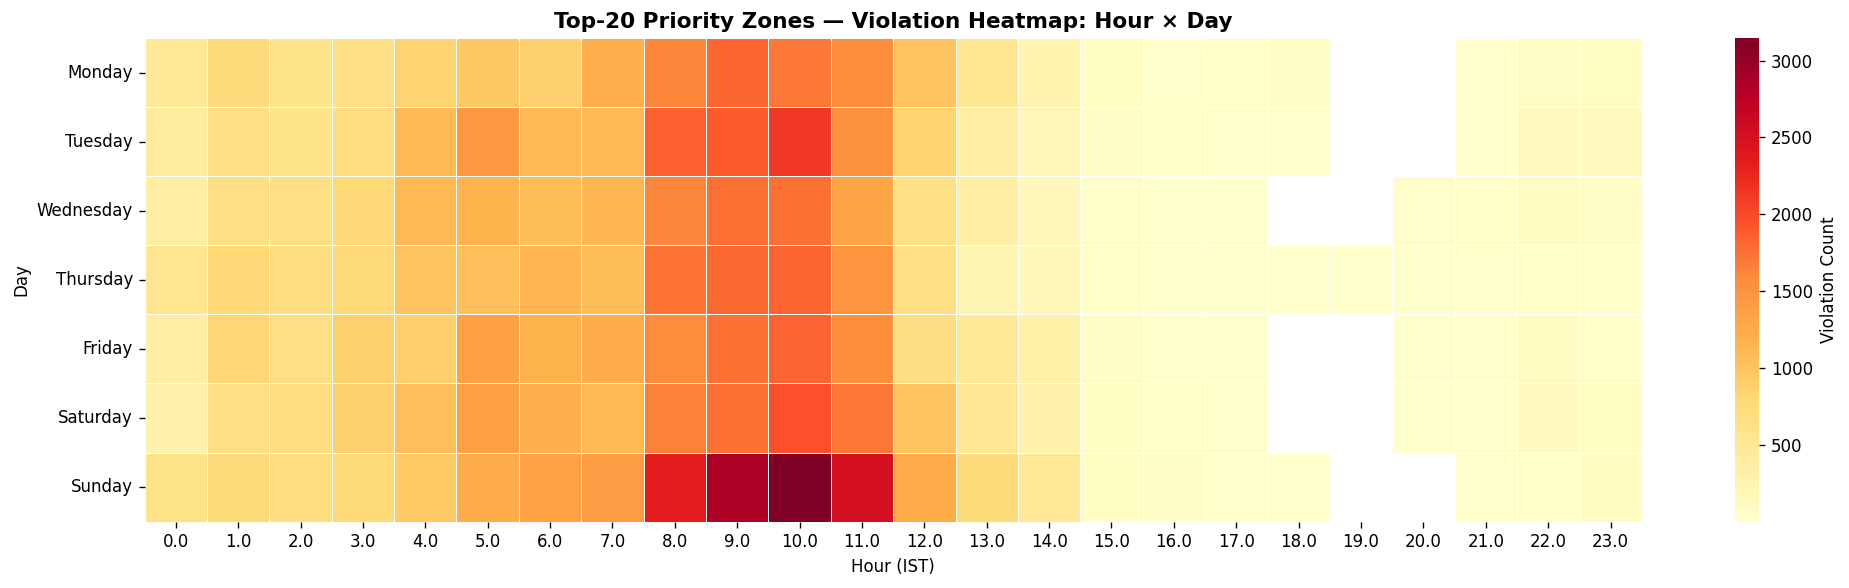

→ Darkest cells = when patrol effort should be highest.


In [6]:
day_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]

# Global hour × day heatmap for top-20 zones
pivot = (df_top.pivot_table(index="day_name", columns="hour",
                             values="id", aggfunc="count")
               .reindex(day_order))

fig, ax = plt.subplots(figsize=(17,5))
sns.heatmap(pivot, cmap="YlOrRd", ax=ax, linewidths=0.3,
            cbar_kws={"label":"Violation Count"})
ax.set_title("Top-20 Priority Zones — Violation Heatmap: Hour × Day")
ax.set_xlabel("Hour (IST)"); ax.set_ylabel("Day")
plt.tight_layout()
plt.savefig(PROCESSED/"temporal_01_heatmap_top20.png", bbox_inches="tight")
plt.show()
print("→ Darkest cells = when patrol effort should be highest.")


Plotting per-zone hour profiles...


Zone profiles: 100%|██████████| 20/20 [00:00<00:00, 21.95it/s]


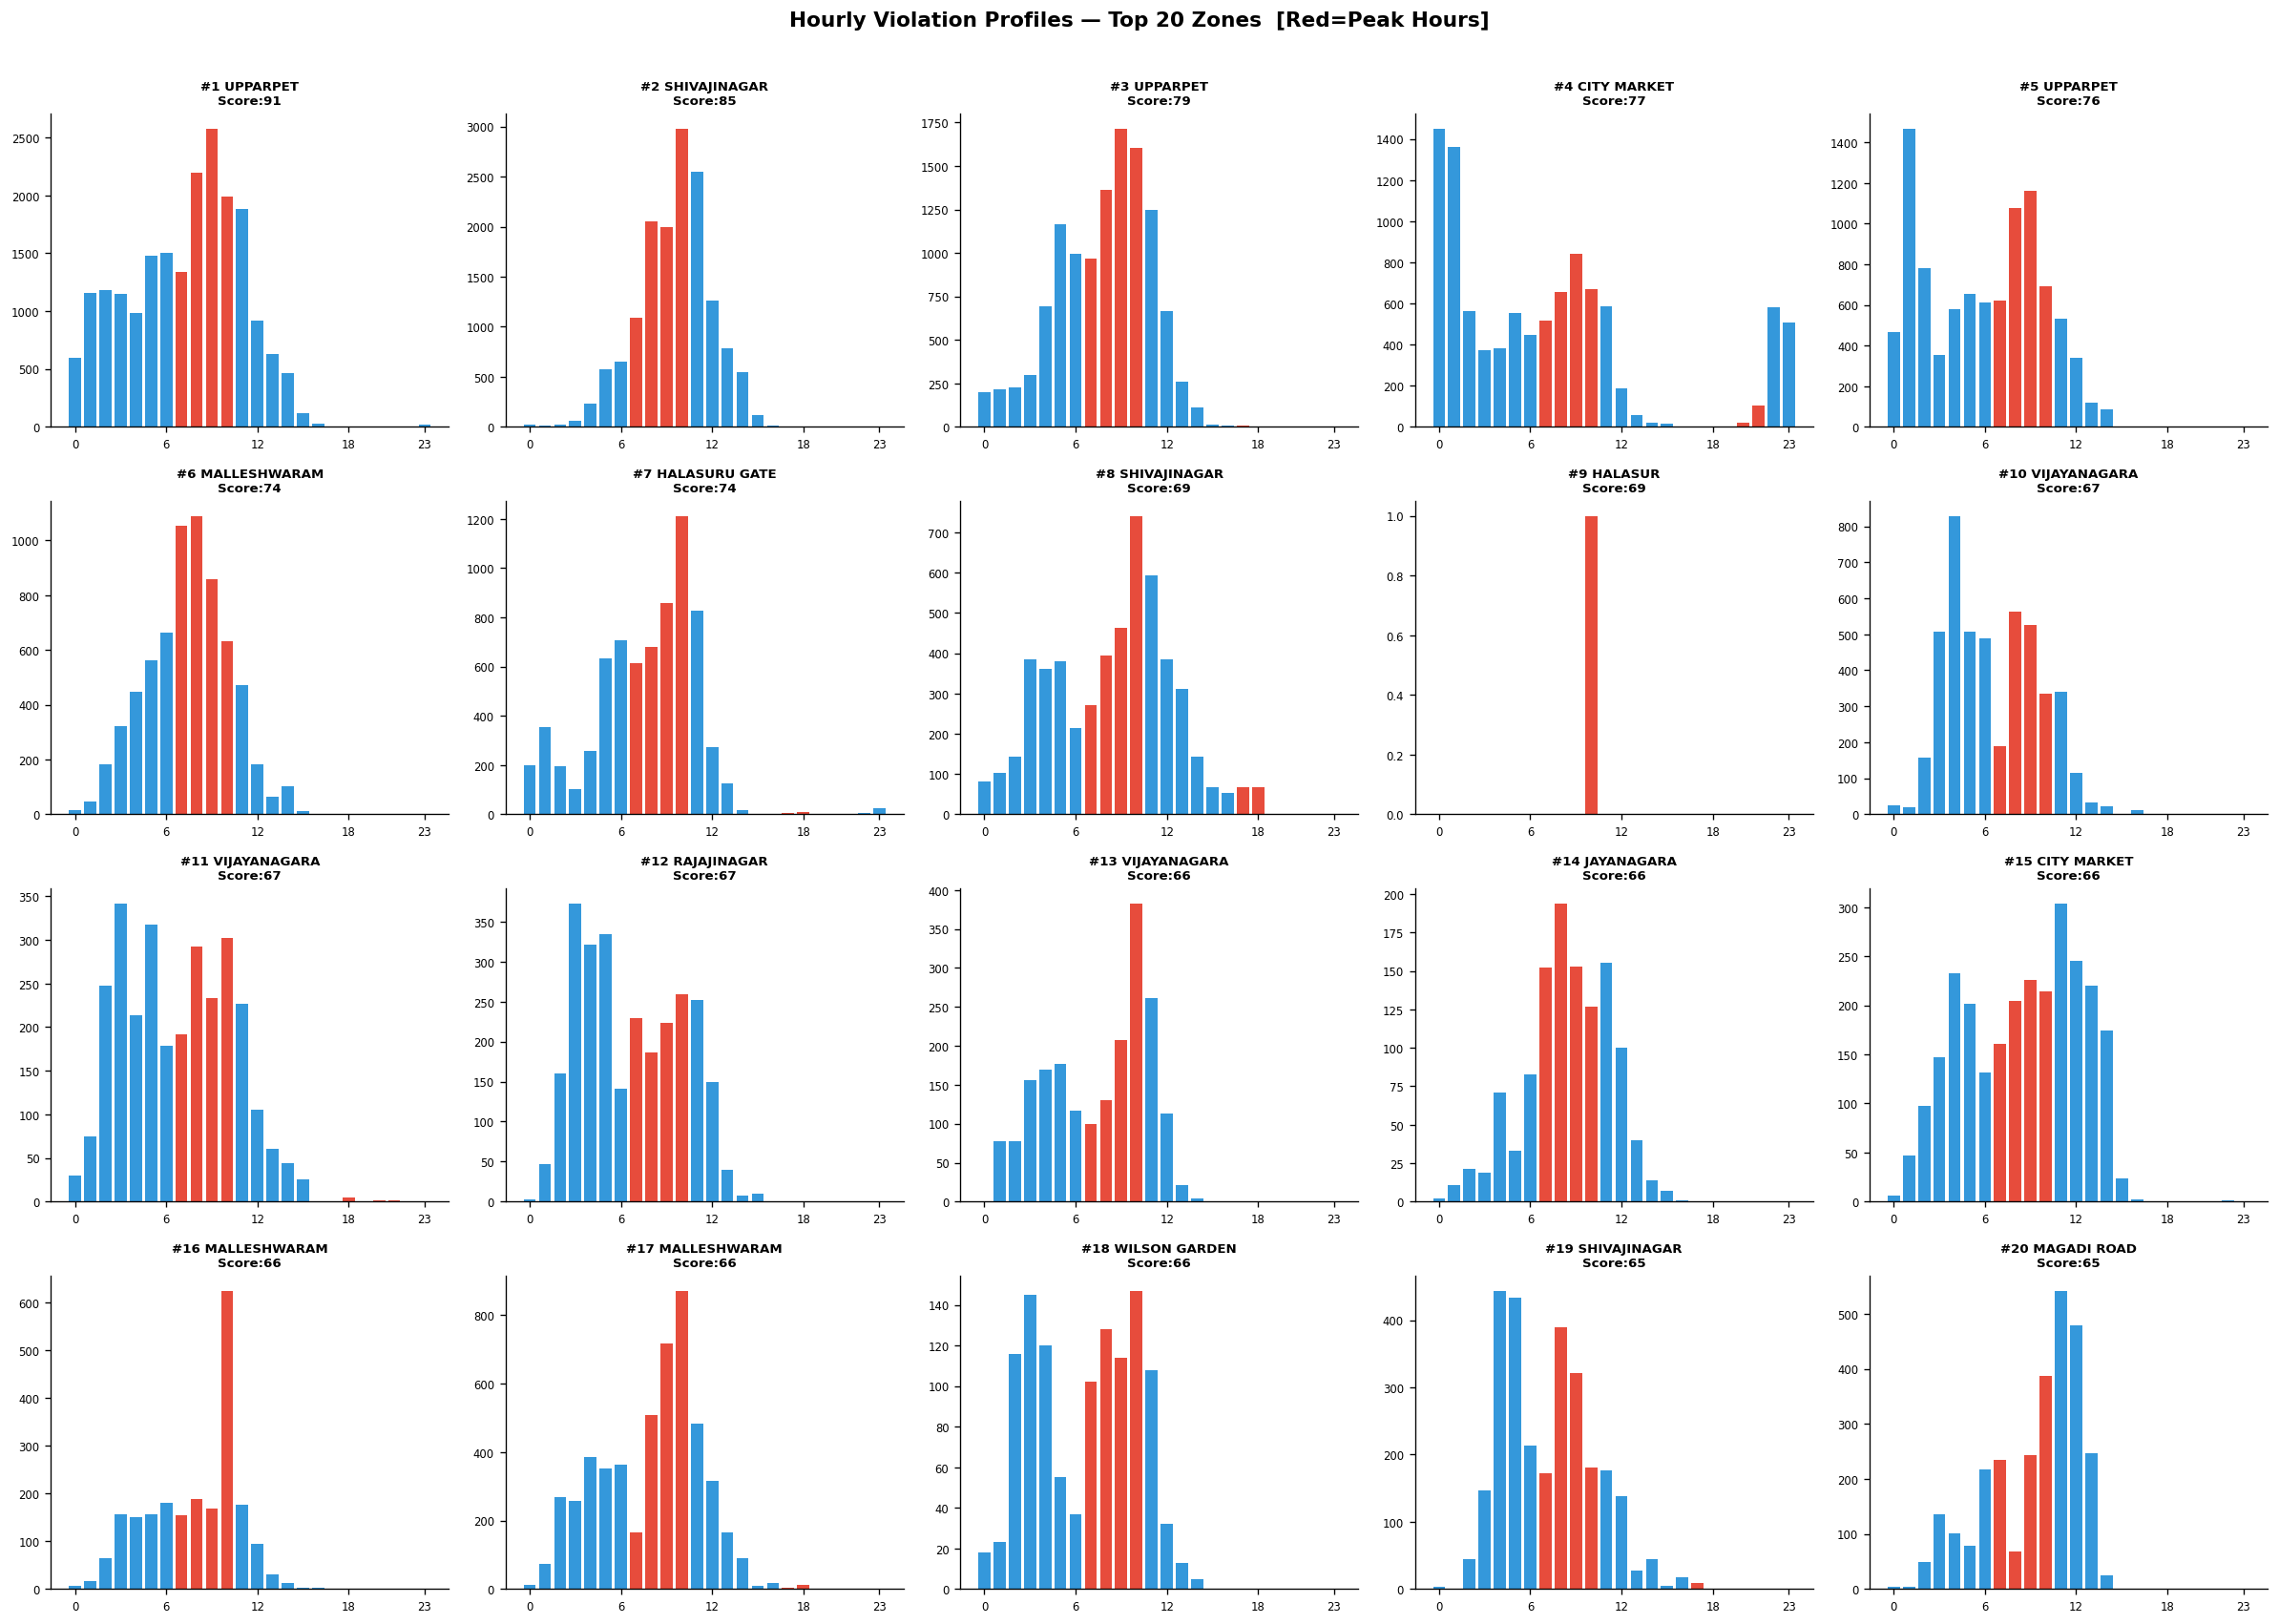

In [7]:
# Per-zone hourly bar chart grid (4×5 for top 20)
fig, axes = plt.subplots(4, 5, figsize=(20,14))
axes = axes.flatten()

print("Plotting per-zone hour profiles...")
for i, h3_id in enumerate(tqdm(top20_ids, desc="Zone profiles")):
    zone_df = df[df["h3_id"]==h3_id]
    hc      = zone_df["hour"].value_counts().sort_index()
    station = hex_df.loc[hex_df["h3_id"]==h3_id,"police_station"].values
    station = station[0] if len(station)>0 else "Unknown"
    score   = hex_df.loc[hex_df["h3_id"]==h3_id,"ensemble_score"].values
    score   = score[0] if len(score)>0 else 0

    colors  = ["#e74c3c" if h in list(range(7,11))+list(range(17,22))
               else "#3498db" for h in range(24)]
    axes[i].bar(range(24), [hc.get(h,0) for h in range(24)],
                color=colors, width=0.8)
    axes[i].set_title(f"#{i+1} {station[:18]}\nScore:{score:.0f}", fontsize=8)
    axes[i].set_xticks([0,6,12,18,23])
    axes[i].tick_params(labelsize=7)

plt.suptitle("Hourly Violation Profiles — Top 20 Zones  [Red=Peak Hours]",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(PROCESSED/"temporal_02_zone_hourprofiles.png",
            bbox_inches="tight", dpi=130)
plt.show()


## 4. Build Zone Temporal Profiles

Per zone: peak hour, best patrol windows, peak day, violation mix, vehicle mix.
These are the context objects fed to the GenAI assistant later.


In [8]:
zone_profiles = []

print("Building zone temporal profiles...")
for h3_id in tqdm(top20_ids, desc="Profiles"):
    zone_df = df[df["h3_id"]==h3_id].copy()
    if len(zone_df) == 0: continue

    hour_counts = zone_df["hour"].value_counts().sort_index()
    peak_hour   = int(hour_counts.idxmax()) if len(hour_counts)>0 else 8

    # Best 2-hour morning window (6–12)
    morning = hour_counts[hour_counts.index.isin(range(6,12))]
    best_morning_start = int(morning.rolling(2).sum().idxmax())-1 if len(morning)>=2 else 8

    # Best 2-hour evening window (14–22)
    evening = hour_counts[hour_counts.index.isin(range(14,23))]
    best_evening_start = int(evening.rolling(2).sum().idxmax())-1 if len(evening)>=2 else 17

    day_counts = zone_df["day_name"].value_counts()
    peak_day   = day_counts.idxmax() if len(day_counts)>0 else "Monday"
    wknd_ratio = float(zone_df["is_weekend"].mean())

    all_v = [v for lst in zone_df["violation_list"] for v in lst]
    top_v = pd.Series(all_v).value_counts().head(3).index.tolist() if all_v else []
    top_veh = zone_df["vehicle_type"].value_counts().head(2).index.tolist()

    row_hex = hex_df[hex_df["h3_id"]==h3_id]
    rh      = row_hex.iloc[0] if len(row_hex)>0 else {}

    zone_profiles.append({
        "h3_id"              : h3_id,
        "ensemble_score"     : float(rh.get("ensemble_score",0)),
        "priority_tier"      : str(rh.get("final_priority_tier","Medium")),
        "police_station"     : str(rh.get("police_station","Unknown")),
        "top_junction"       : str(rh.get("top_junction","No Junction")),
        "violation_count"    : int(rh.get("violation_count",0)),
        "lat"                : float(rh.get("lat",12.97)),
        "lon"                : float(rh.get("lon",77.59)),
        "peak_hour"          : peak_hour,
        "best_morning_start" : best_morning_start,
        "best_evening_start" : best_evening_start,
        "peak_day"           : peak_day,
        "weekend_ratio"      : round(wknd_ratio,3),
        "top_violations"     : top_v,
        "top_vehicles"       : top_veh,
        "hourly_counts"      : hour_counts.to_dict(),
        "daily_counts"       : day_counts.to_dict(),
        "severity_mean"      : float(rh.get("severity_mean",0)),
        "near_junction_ratio": float(rh.get("near_junction_ratio",0)),
        "peak_hour_ratio"    : float(rh.get("peak_hour_ratio",0)),
    })

zone_profile_df = pd.DataFrame(zone_profiles)
print(f"\n✅ Built profiles for {len(zone_profile_df)} zones")
print(zone_profile_df[["police_station","peak_hour","peak_day",
                         "top_violations","ensemble_score"]].head(10).to_string())


Building zone temporal profiles...


Profiles: 100%|██████████| 20/20 [00:00<00:00, 32.56it/s]


✅ Built profiles for 20 zones
  police_station  peak_hour  peak_day                                                    top_violations  ensemble_score
0       UPPARPET          9  Saturday  [WRONG PARKING, NO PARKING, WRONG PARKINGDEFECTIVE NUMBER PLATE]       90.826864
1   SHIVAJINAGAR         10    Sunday  [WRONG PARKING, NO PARKING, WRONG PARKINGDEFECTIVE NUMBER PLATE]       85.072219
2       UPPARPET          9    Sunday  [WRONG PARKING, NO PARKING, WRONG PARKINGPARKING IN A MAIN ROAD]       79.361419
3    CITY MARKET          0    Sunday  [WRONG PARKING, NO PARKING, PARKING IN A MAIN ROADWRONG PARKING]       76.937188
4       UPPARPET          1    Sunday     [NO PARKING, WRONG PARKING, NO PARKINGDEFECTIVE NUMBER PLATE]       75.760048
5   MALLESHWARAM          8    Sunday  [WRONG PARKING, NO PARKING, WRONG PARKINGDEFECTIVE NUMBER PLATE]       74.329496
6  HALASURU GATE         10   Tuesday  [WRONG PARKING, NO PARKING, WRONG PARKINGDEFECTIVE NUMBER PLATE]       73.545146
7   SHIVA

## 5. Prophet Forecasting — 30-Day Ahead Predictions

Fits a daily time-series model on each of the top 5 critical zones.
Captures weekly seasonality (Mon–Sun patterns) automatically.
Output: forecast with 80% confidence interval + trend direction.


In [9]:
from prophet import Prophet
import joblib

TOP5_IDS = top20_ids[:5]
forecast_results = {}

print("Fitting Prophet for top 5 zones...")
print("(Each model: ~10–20 seconds)")
print()

for h3_id in TOP5_IDS:
    zone_df = df[df["h3_id"]==h3_id].copy()
    station = hex_df.loc[hex_df["h3_id"]==h3_id,"police_station"].values
    station = station[0] if len(station)>0 else "Unknown"

    daily = (zone_df.groupby("date")
                    .agg(y=("id","count"))
                    .reset_index()
                    .rename(columns={"date":"ds"}))
    daily["ds"] = pd.to_datetime(daily["ds"])
    daily = daily.sort_values("ds").reset_index(drop=True)

    if len(daily) < 10:
        print(f"  ⚠️  Skipping {station} — only {len(daily)} days of data")
        continue

    # Threading spinner (same pattern as your Day 2 DBSCAN)
    stop_event = threading.Event()
    def _spinner(stop, name):
        start = time.time()
        while not stop.is_set():
            time.sleep(0.5)
            if not stop.is_set():
                print(f"\r  ⏳ Fitting Prophet for {name}... ({time.time()-start:.0f}s)", end="")
    t = threading.Thread(target=_spinner, args=(stop_event, station[:25]))
    t.start()

    try:
        model_p = Prophet(
            yearly_seasonality=False,
            weekly_seasonality=True,
            daily_seasonality=False,
            interval_width=0.8,
            changepoint_prior_scale=0.05,
        )
        model_p.fit(daily)
        future   = model_p.make_future_dataframe(periods=30)
        forecast = model_p.predict(future)
    finally:
        stop_event.set(); t.join()
        print(f"\r  ✅ Done: {station[:30]:<30s}", end="\n")

    forecast_results[h3_id] = {
        "station" : station,
        "daily"   : daily,
        "forecast": forecast[["ds","yhat","yhat_lower","yhat_upper"]].copy(),
    }
    joblib.dump(model_p, MODELS/f"prophet_{h3_id[:8]}.joblib")

print(f"\n✅ Prophet complete. Models saved to {MODELS}/")


22:52:01 - cmdstanpy - INFO - Chain [1] start processing


Fitting Prophet for top 5 zones...
(Each model: ~10–20 seconds)

  ⏳ Fitting Prophet for UPPARPET... (1s)

22:52:02 - cmdstanpy - INFO - Chain [1] done processing


  ✅ Done: UPPARPET                      


22:52:02 - cmdstanpy - INFO - Chain [1] start processing
22:52:02 - cmdstanpy - INFO - Chain [1] done processing
22:52:03 - cmdstanpy - INFO - Chain [1] start processing


...

  ✅ Done: UPPARPET                      


22:52:03 - cmdstanpy - INFO - Chain [1] done processing
22:52:04 - cmdstanpy - INFO - Chain [1] start processing


  ✅ Done: CITY MARKET                   


22:52:04 - cmdstanpy - INFO - Chain [1] done processing


  ✅ Done: UPPARPET                      

✅ Prophet complete. Models saved to D:\Coding Stuff\grid2\models/


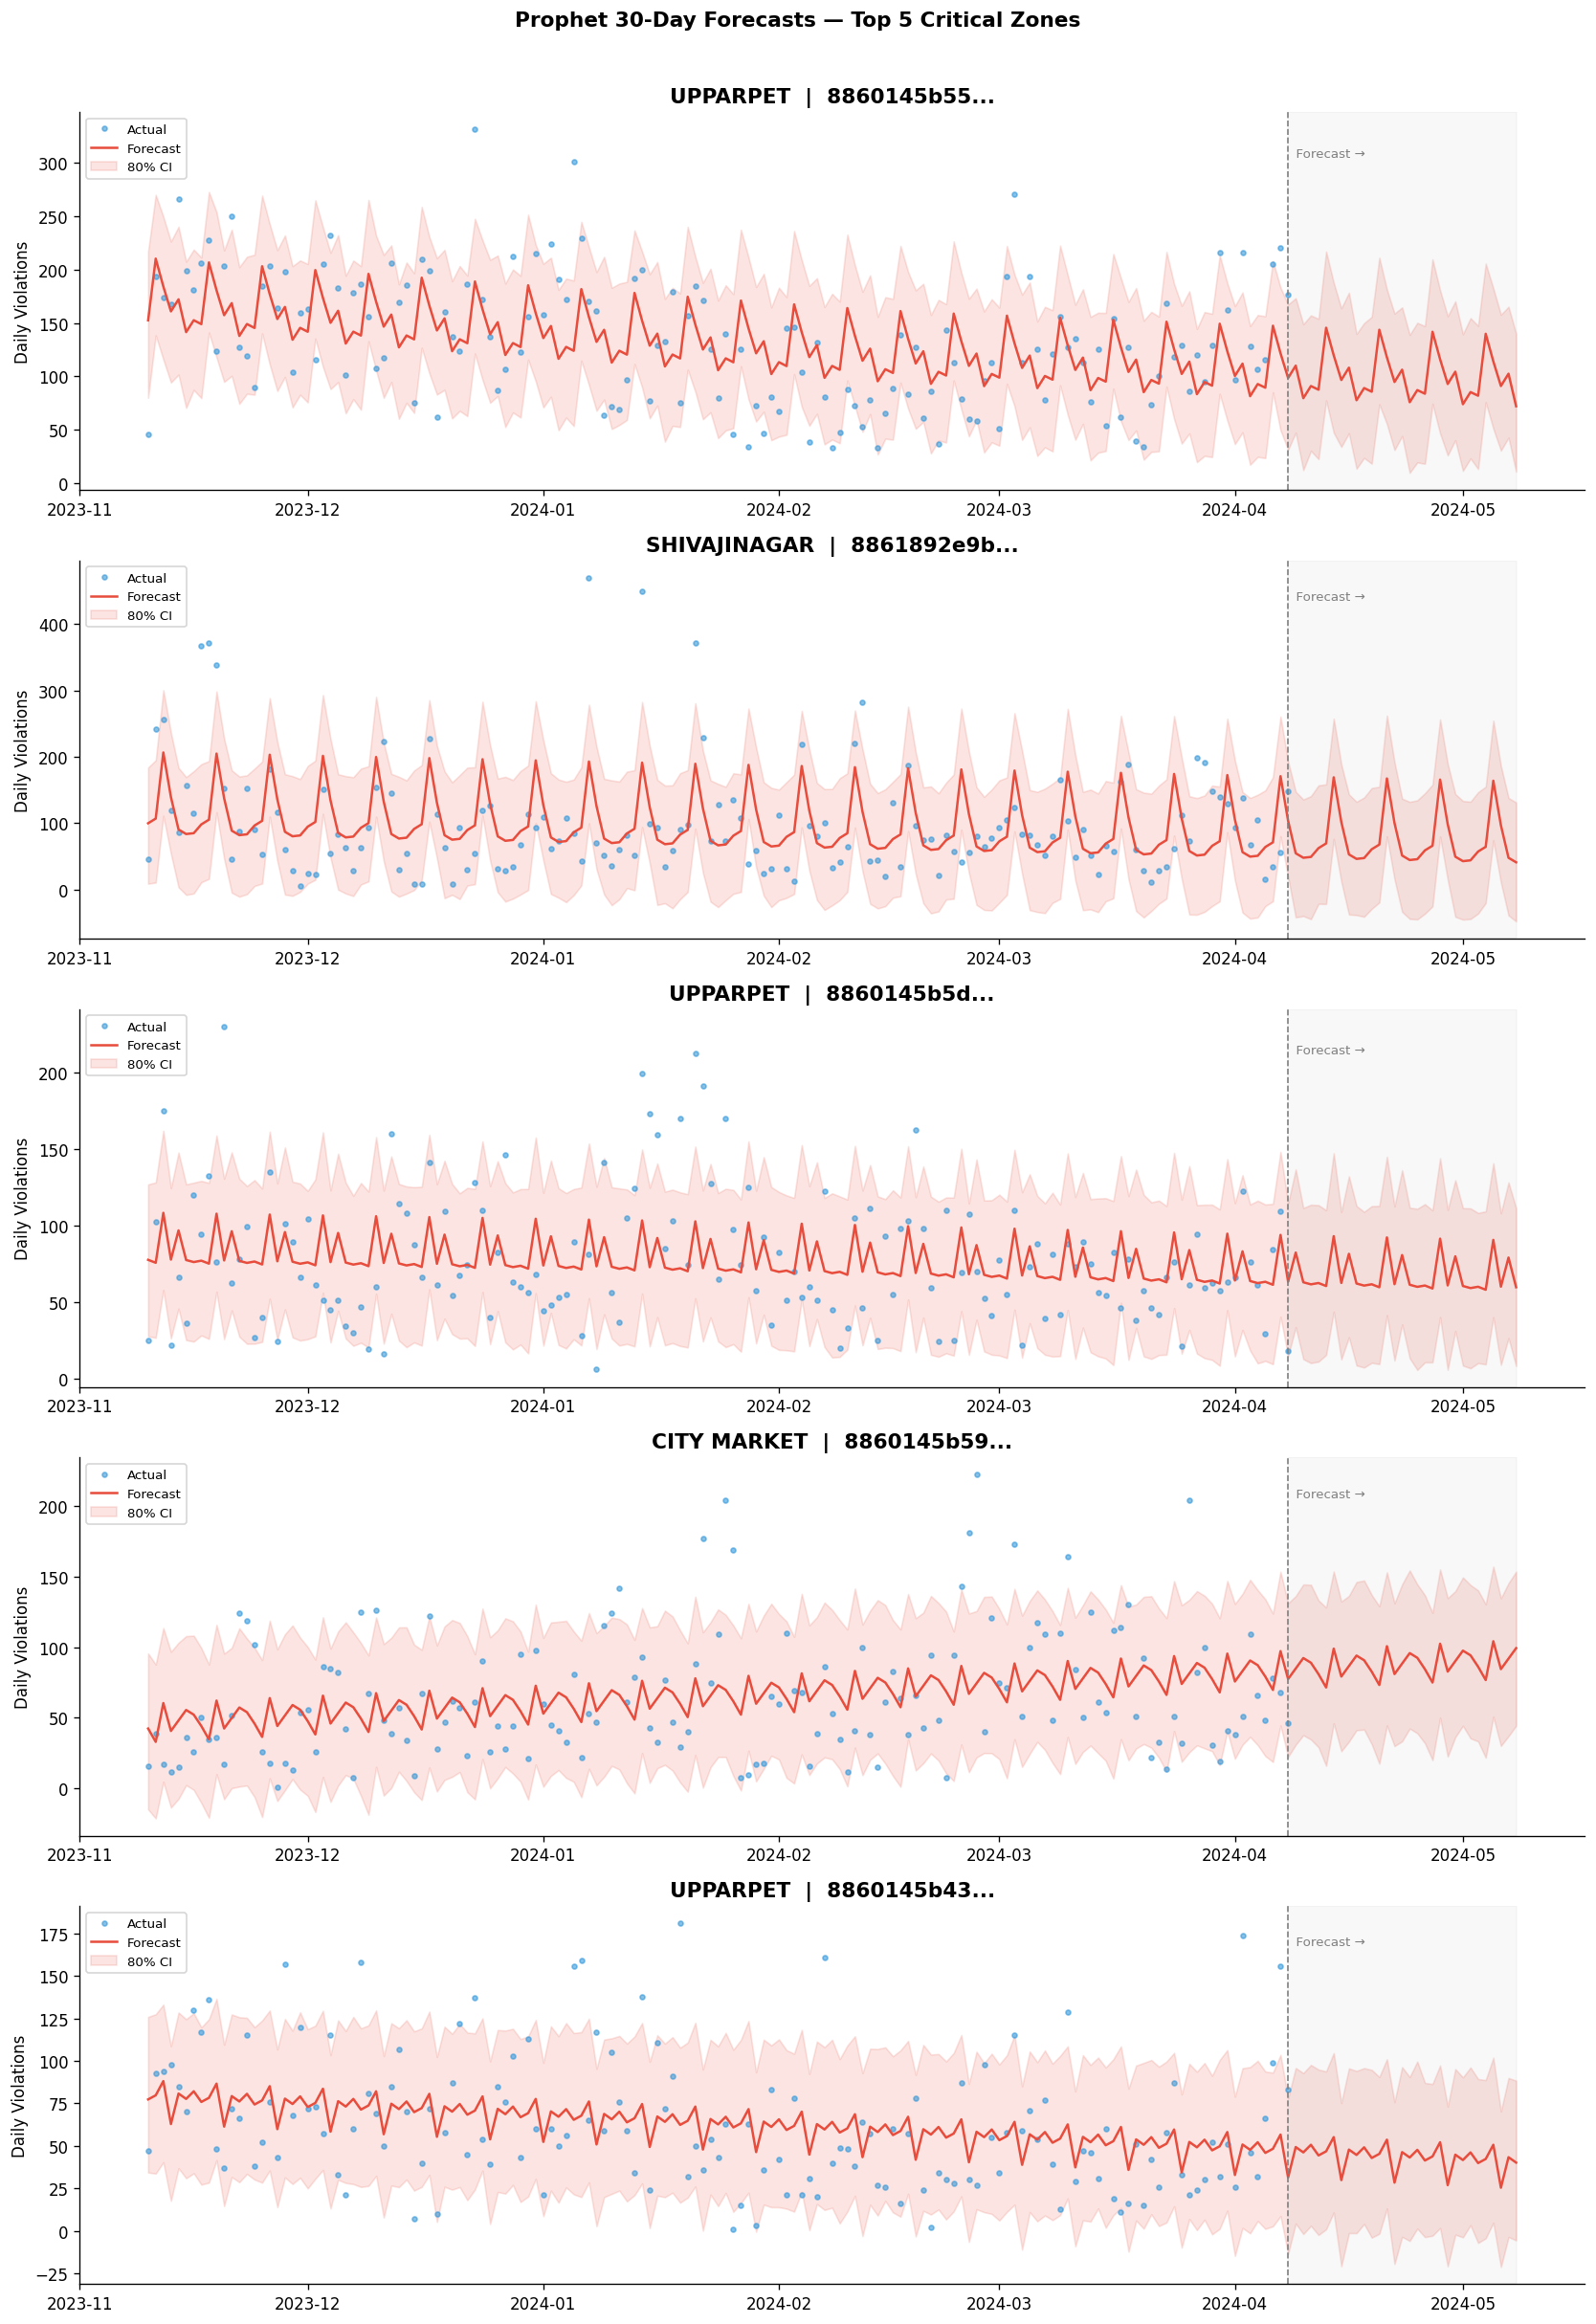

In [10]:
# Plot forecasts
n = len(forecast_results)
fig, axes = plt.subplots(n, 1, figsize=(14, 4*n))
if n == 1: axes = [axes]

for ax, (h3_id, res) in zip(axes, forecast_results.items()):
    daily    = res["daily"]
    forecast = res["forecast"]
    station  = res["station"]

    ax.plot(daily["ds"], daily["y"], "o", color="#3498db", ms=3, alpha=0.6, label="Actual")
    ax.plot(forecast["ds"], forecast["yhat"], "-", color="#e74c3c", lw=1.5, label="Forecast")
    ax.fill_between(forecast["ds"], forecast["yhat_lower"], forecast["yhat_upper"],
                    alpha=0.15, color="#e74c3c", label="80% CI")

    split = daily["ds"].max()
    future_fc = forecast[forecast["ds"] > split]
    ax.axvspan(split, future_fc["ds"].max(), alpha=0.05, color="gray")
    ax.axvline(split, color="gray", ls="--", lw=1)
    ax.text(split, ax.get_ylim()[1]*0.88, "  Forecast →", fontsize=8, color="gray")
    ax.set_title(f"{station}  |  {h3_id[:10]}...")
    ax.set_ylabel("Daily Violations")
    ax.legend(fontsize=8, loc="upper left")

plt.suptitle("Prophet 30-Day Forecasts — Top 5 Critical Zones",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(PROCESSED/"temporal_03_prophet_forecasts.png", bbox_inches="tight", dpi=120)
plt.show()


In [11]:
# Trend summary
print("=" * 62)
print("ZONE TREND SUMMARY  (last 2 weeks vs previous 2 weeks)")
print("=" * 62)
for h3_id, res in forecast_results.items():
    daily = res["daily"]
    if len(daily) < 14: continue
    recent  = daily.tail(14)["y"].mean()
    earlier = daily.iloc[-28:-14]["y"].mean() if len(daily)>=28 else daily.head(14)["y"].mean()
    delta   = recent - earlier
    if delta > earlier*0.1:   icon = "📈 INCREASING"
    elif delta < -earlier*0.1: icon = "📉 DECREASING"
    else:                     icon = "➡️  STABLE"
    print(f"  {res['station'][:32]:32s}  {icon}  "
          f"(recent: {recent:.1f}/day | prev: {earlier:.1f}/day | Δ{delta:+.1f})")


ZONE TREND SUMMARY  (last 2 weeks vs previous 2 weeks)
  UPPARPET                          📈 INCREASING  (recent: 148.1/day | prev: 98.1/day | Δ+49.9)
  SHIVAJINAGAR                      📈 INCREASING  (recent: 110.1/day | prev: 69.9/day | Δ+40.2)
  UPPARPET                          📈 INCREASING  (recent: 68.6/day | prev: 59.0/day | Δ+9.6)
  CITY MARKET                       ➡️  STABLE  (recent: 70.1/day | prev: 67.2/day | Δ+2.9)
  UPPARPET                          📈 INCREASING  (recent: 63.7/day | prev: 38.7/day | Δ+25.0)


## 6. Patrol Scheduler

Given current hour + day → ranked list of zones to patrol.
Boosts score for zones whose historical peak matches query time.
Also builds a full 7-day × 6-slot patrol calendar.


In [12]:
def get_patrol_recommendations(hour: int, day_name: str, top_n: int=5) -> pd.DataFrame:
    """
    Return top_n zones ranked by time-adjusted priority score.
    Time boost: zones peaking at `hour` on `day_name` get +40% / +20%.
    """
    recs = []
    for _, row in zone_profile_df.iterrows():
        base       = row["ensemble_score"]
        hourly     = row["hourly_counts"]
        day_c      = row["daily_counts"]
        total_h    = max(sum(hourly.values()), 1)
        total_d    = max(sum(day_c.values()), 1)
        time_rel   = hourly.get(hour, hourly.get(str(hour), 0)) / total_h
        day_rel    = day_c.get(day_name, 0) / total_d
        adj_score  = base * (1 + 0.4*time_rel + 0.2*day_rel)

        recs.append({
            "h3_id"          : row["h3_id"],
            "police_station" : row["police_station"],
            "top_junction"   : row["top_junction"],
            "base_score"     : round(base, 1),
            "time_adj_score" : round(adj_score, 1),
            "priority_tier"  : row["priority_tier"],
            "peak_hour"      : row["peak_hour"],
            "peak_day"       : row["peak_day"],
            "top_violations" : ", ".join(row["top_violations"][:2]),
            "top_vehicles"   : ", ".join(row["top_vehicles"][:2]),
            "lat"            : row["lat"],
            "lon"            : row["lon"],
        })

    result = (pd.DataFrame(recs)
                .sort_values("time_adj_score", ascending=False)
                .head(top_n)
                .reset_index(drop=True))
    result.index += 1
    result.index.name = "rank"
    return result


In [13]:
import datetime

now_ist      = datetime.datetime.now(datetime.timezone(datetime.timedelta(hours=5, minutes=30)))
current_hour = now_ist.hour
current_day  = now_ist.strftime("%A")

print(f"Current IST: {now_ist.strftime('%H:%M')} on {current_day}")
print()
recs = get_patrol_recommendations(current_hour, current_day, top_n=10)
print("TOP 10 ZONES TO PATROL RIGHT NOW:")
print(recs[["police_station","top_junction","time_adj_score",
             "priority_tier","top_violations","top_vehicles"]].to_string())


Current IST: 22:52 on Tuesday

TOP 10 ZONES TO PATROL RIGHT NOW:
     police_station                        top_junction  time_adj_score priority_tier             top_violations             top_vehicles
rank                                                                                                                                     
1          UPPARPET             BTP040 - ELITE JUNCTION            93.4      Critical  WRONG PARKING, NO PARKING             SCOOTER, CAR
2      SHIVAJINAGAR      BTP051 - SAFINA PLAZA JUNCTION            86.8      Critical  WRONG PARKING, NO PARKING  SCOOTER, PASSENGER AUTO
3          UPPARPET     BTP044 - SAGAR THEATRE JUNCTION            81.9          High  WRONG PARKING, NO PARKING  SCOOTER, PASSENGER AUTO
4       CITY MARKET         BTP082 - KR MARKET JUNCTION            80.9          High  WRONG PARKING, NO PARKING  SCOOTER, PASSENGER AUTO
5          UPPARPET     BTP044 - SAGAR THEATRE JUNCTION            78.0          High  NO PARKING, WRONG PA

In [14]:
# Full-week patrol calendar
slots    = [(6,"06–09"),(9,"09–12"),(12,"12–15"),(15,"15–18"),(18,"18–21"),(21,"21–24")]
days     = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]

print("Building full-week patrol calendar...")
cal_rows = []
for day in tqdm(days, desc="Days"):
    for slot_hour, slot_label in slots:
        top3 = get_patrol_recommendations(slot_hour, day, top_n=3)
        for rank, (_, row) in enumerate(top3.iterrows(), 1):
            cal_rows.append({
                "day":day, "time_slot":slot_label, "rank":rank,
                "station":row["police_station"], "junction":row["top_junction"],
                "score":row["time_adj_score"], "tier":row["priority_tier"],
            })

calendar_df = pd.DataFrame(cal_rows)
print(f"✅ Calendar: {len(calendar_df)} recommendations ({len(days)*len(slots)} slots × 3 zones)")


Building full-week patrol calendar...


Days: 100%|██████████| 7/7 [00:00<00:00, 97.85it/s]

✅ Calendar: 126 recommendations (42 slots × 3 zones)


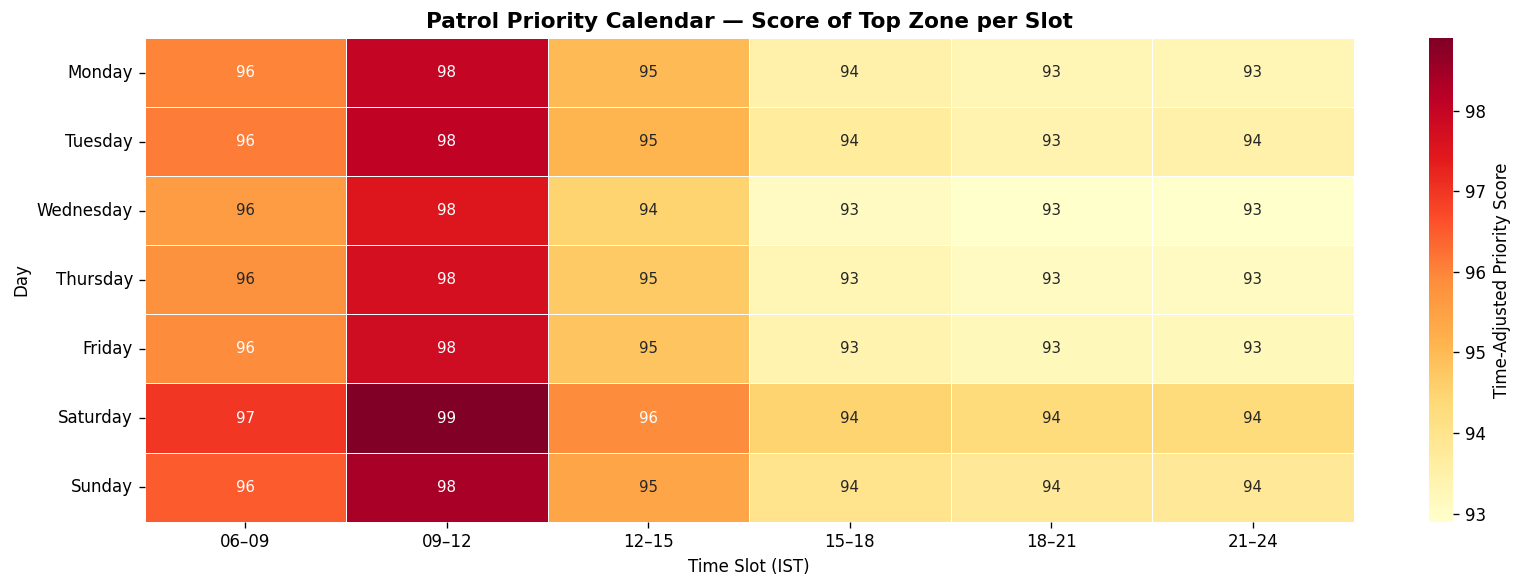

In [ ]:
# Heatmap — score of top zone per slot
pivot_score = calendar_df[calendar_df["rank"]==1].pivot_table(
    index="day", columns="time_slot", values="score", aggfunc="first"
).reindex(days)

fig, ax = plt.subplots(figsize=(14,5))
sns.heatmap(pivot_score, cmap="YlOrRd", ax=ax, linewidths=0.5,
            annot=True, fmt=".0f", annot_kws={"size":9},
            cbar_kws={"label":"Time-Adjusted Priority Score"})
ax.set_title("Patrol Priority Calendar — Score of Top Zone per Slot")
ax.set_xlabel("Time Slot (IST)"); ax.set_ylabel("Day")
plt.tight_layout()
plt.savefig(PROCESSED/"temporal_04_patrol_calendar.png", bbox_inches="tight")
plt.show()


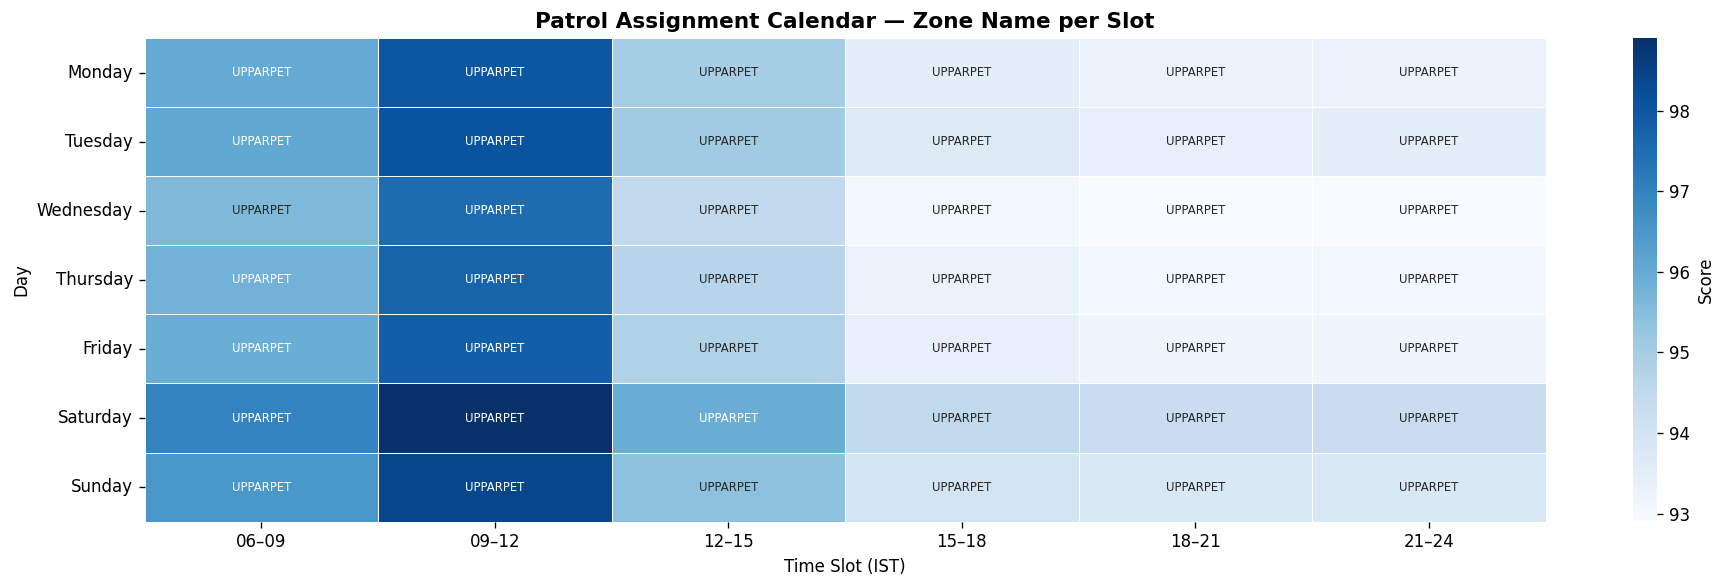

In [16]:
# Heatmap — which zone name per slot
pivot_names = calendar_df[calendar_df["rank"]==1].pivot_table(
    index="day", columns="time_slot", values="station", aggfunc="first"
).reindex(days)
pivot_score2 = calendar_df[calendar_df["rank"]==1].pivot_table(
    index="day", columns="time_slot", values="score", aggfunc="first"
).reindex(days)

fig, ax = plt.subplots(figsize=(16,5))
annot = pivot_names.applymap(lambda x: x[:14] if isinstance(x,str) else "")
sns.heatmap(pivot_score2, cmap="Blues", ax=ax, linewidths=0.5,
            annot=annot, fmt="", annot_kws={"size":7},
            cbar_kws={"label":"Score"})
ax.set_title("Patrol Assignment Calendar — Zone Name per Slot")
ax.set_xlabel("Time Slot (IST)"); ax.set_ylabel("Day")
plt.tight_layout()
plt.savefig(PROCESSED/"temporal_05_patrol_assignments.png", bbox_inches="tight")
plt.show()


## 7. GenAI Assistant — Gemini 2.5 Flash

Answers plain-English questions from traffic inspectors.
Grounded in actual zone data — never hallucinates numbers it doesn't have.

Model: `gemini-2.5-flash` (fast, free tier, strong reasoning).
Fallback: `gemini-2.5-pro` for complex multi-zone analysis.


In [17]:
import google.generativeai as genai

GOOGLE_API_KEY = os.getenv("GOOGLE_API_KEY","")
if not GOOGLE_API_KEY:
    print("⚠️  GOOGLE_API_KEY not in .env — GenAI cells will print placeholder.")
    GENAI_AVAILABLE = False
else:
    genai.configure(api_key=GOOGLE_API_KEY)
    gemini_flash = genai.GenerativeModel("gemini-2.5-flash")
    gemini_pro   = genai.GenerativeModel("gemini-2.5-pro")   # for complex queries
    GENAI_AVAILABLE = True
    print("✅ Gemini 2.5 Flash + Pro connected.")


✅ Gemini 2.5 Flash + Pro connected.


In [18]:
SYSTEM_PROMPT = """You are ParkSentinel, an AI assistant embedded in Bengaluru Traffic Police's
enforcement intelligence system. You help inspectors understand parking violation hotspots
and plan targeted enforcement.

Strict rules:
- ALWAYS cite specific numbers from the data context. Never invent statistics.
- If a zone or location is not in the context, say so clearly.
- Answers must be operational: tell the inspector WHAT to do and WHEN.
- Keep answers under 200 words unless a detailed breakdown is explicitly requested.
- Use plain English — inspectors are not data scientists.
- Suggest specific patrol time windows based on peak hours in the data.
"""


def build_context(top_n: int=10, station_filter: str=None) -> str:
    """Build structured text context from zone profiles for Gemini prompt."""
    zones = zone_profile_df.copy()
    if station_filter:
        zones = zones[zones["police_station"].str.contains(
            station_filter, case=False, na=False)]
    zones = zones.nlargest(top_n, "ensemble_score")

    lines = ["=== BENGALURU PARKING VIOLATION INTELLIGENCE DATA ===\n"]
    for i, (_, row) in enumerate(zones.iterrows(), 1):
        lines.append(
            f"ZONE #{i} | Station: {row['police_station']} | "
            f"Junction: {row['top_junction']}\n"
            f"  Priority Score: {row['ensemble_score']:.1f}/100 | Tier: {row['priority_tier']}\n"
            f"  Total Violations (Jan-May): {row['violation_count']:,}\n"
            f"  Peak Hour: {row['peak_hour']}:00 IST | Peak Day: {row['peak_day']}\n"
            f"  Best Morning Patrol: {row['best_morning_start']}:00–{row['best_morning_start']+2}:00\n"
            f"  Best Evening Patrol: {row['best_evening_start']}:00–{row['best_evening_start']+2}:00\n"
            f"  Weekend share: {row['weekend_ratio']*100:.0f}%\n"
            f"  Near named junction: {row['near_junction_ratio']*100:.0f}% of violations\n"
            f"  Peak-hour violations: {row['peak_hour_ratio']*100:.0f}%\n"
            f"  Top violations: {', '.join(row['top_violations']) or 'N/A'}\n"
            f"  Top vehicle types: {', '.join(row['top_vehicles']) or 'N/A'}\n"
            f"  Avg severity score: {row['severity_mean']:.2f}/5\n"
        )
    return "\n".join(lines)


def ask(question: str, use_pro: bool=False,
        station_filter: str=None, top_n: int=10) -> str:
    """
    Ask ParkSentinel a question.
    use_pro=True → Gemini 2.5 Pro (slower but more thorough).
    """
    if not GENAI_AVAILABLE:
        return "[GenAI unavailable — add GOOGLE_API_KEY to .env]"

    context = build_context(top_n=top_n, station_filter=station_filter)
    prompt  = f"{SYSTEM_PROMPT}\n\n{context}\n\nInspector: {question}\n\nParkSentinel:"
    model   = gemini_pro if use_pro else gemini_flash
    return model.generate_content(prompt).text


print("✅ ask() ready. Usage:")
print("   ask('Where should I patrol at 8 AM on Monday?')")
print("   ask('Detailed breakdown of top 3 zones', use_pro=True)")


✅ ask() ready. Usage:
   ask('Where should I patrol at 8 AM on Monday?')
   ask('Detailed breakdown of top 3 zones', use_pro=True)


In [19]:
# Demo Q&A — 4 realistic inspector questions
if GENAI_AVAILABLE:
    questions = [
        "Which zone should I send a patrol to right now during morning rush?",
        "Give me the top 3 most critical zones and why each is flagged.",
        "Which vehicle types cause the worst congestion and in which zones?",
        "Should I increase weekend patrols or focus on weekdays?",
    ]
    for i, q in enumerate(questions, 1):
        print(f"{'='*65}")
        print(f"Q{i}: {q}")
        print(f"{'─'*65}")
        print(ask(q, top_n=10))
        print()


Q1: Which zone should I send a patrol to right now during morning rush?
─────────────────────────────────────────────────────────────────
Inspector, for morning rush enforcement, prioritize **ZONE #1: BTP040 - ELITE JUNCTION (Upparpet Station)**.

This zone has the highest Priority Score of **90.8/100** and is a Critical tier hotspot, with **20,216** violations recorded from Jan-May. Its peak hour is 9:00 IST.

Deploy a patrol immediately for the **Best Morning Patrol window: 8:00–10:00**. Focus on enforcing **WRONG PARKING** and **NO PARKING** violations, which are the most common here. Scooters and Cars are the top vehicle types observed in violations.

Q2: Give me the top 3 most critical zones and why each is flagged.
─────────────────────────────────────────────────────────────────
Inspector, here are the top 3 most critical parking violation zones for targeted enforcement:

1.  **ZONE #1: UPPARPET - ELITE JUNCTION (BTP040)**
    *   **Why flagged:** This is the highest priority zo

In [20]:
# ── Interactive cell — change YOUR_QUESTION and re-run ────────────────────
YOUR_QUESTION = "Which zone peaks on Friday evening and what violation type dominates?"

if GENAI_AVAILABLE:
    print(f"Q: {YOUR_QUESTION}")
    print("─"*65)
    print(ask(YOUR_QUESTION, top_n=10))
else:
    print("Add GOOGLE_API_KEY to .env and re-run.")


Q: Which zone peaks on Friday evening and what violation type dominates?
─────────────────────────────────────────────────────────────────
No zone in the provided data explicitly peaks on a Friday. All listed zones have their peak days on Saturday, Sunday, Monday, or Tuesday.

Therefore, I cannot identify a specific zone that peaks on Friday evening based on this data.


In [21]:
# ── Pro mode demo (more detailed analysis) ────────────────────────────────
PRO_QUESTION = "Give me a detailed enforcement strategy for the top 5 zones covering patrol timing, vehicle focus, and expected impact."

if GENAI_AVAILABLE:
    print(f"Q (Pro mode): {PRO_QUESTION}")
    print("─"*65)
    print(ask(PRO_QUESTION, use_pro=True, top_n=5))


Q (Pro mode): Give me a detailed enforcement strategy for the top 5 zones covering patrol timing, vehicle focus, and expected impact.
─────────────────────────────────────────────────────────────────


ResourceExhausted: 429 You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. 
* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_input_token_count, limit: 0, model: gemini-2.5-pro
* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_input_token_count, limit: 0, model: gemini-2.5-pro
* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 0, model: gemini-2.5-pro
* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 0, model: gemini-2.5-pro
Please retry in 1.152775769s. [links {
  description: "Learn more about Gemini API quotas"
  url: "https://ai.google.dev/gemini-api/docs/rate-limits"
}
, violations {
  quota_metric: "genera

## 8. Save All Outputs

In [23]:
# Zone profiles — JSON-encode list columns for parquet compatibility
zp_save = zone_profile_df.copy()
for col in ["top_violations","top_vehicles","hourly_counts","daily_counts"]:
    zp_save[col] = zp_save[col].apply(json.dumps)

zp_out = PROCESSED/"zone_profiles_day3.parquet"
zp_save.to_parquet(zp_out, index=False)
print(f"✅ Zone profiles       → {zp_out}")

cal_out = PROCESSED/"patrol_calendar.parquet"
calendar_df.to_parquet(cal_out, index=False)
print(f"✅ Patrol calendar     → {cal_out}")

# Handle the _x suffix created during the merge
ps_col = "police_station_x" if "police_station_x" in df.columns else "police_station"

# Full violations with h3_id for dashboard map layer
df_map_out = PROCESSED/"violations_with_h3.parquet"
export_cols = ["id","h3_id","latitude","longitude","hour","day_name",
               "severity_score","impact_score","is_peak_hour","near_junction",
               "vehicle_type", ps_col, "created_ist"]

df_export = df[export_cols].copy()
df_export.rename(columns={ps_col: "police_station"}, inplace=True)

df_export.to_parquet(df_map_out, index=False)
print(f"✅ Violations+H3       → {df_map_out}")

# Human-readable schedule
cal_pivot = calendar_df[calendar_df["rank"]==1].pivot_table(
    index="day", columns="time_slot", values="station", aggfunc="first"
).reindex(days)
cal_pivot.to_csv(PROCESSED/"patrol_schedule_readable.csv")
print(f"✅ Readable schedule   → {PROCESSED/'patrol_schedule_readable.csv'}")

print("\n🎉 DAY 3 COMPLETE! You are ready to launch the Streamlit Dashboard.")

✅ Zone profiles       → D:\Coding Stuff\grid2\data\processed\zone_profiles_day3.parquet
✅ Patrol calendar     → D:\Coding Stuff\grid2\data\processed\patrol_calendar.parquet
✅ Violations+H3       → D:\Coding Stuff\grid2\data\processed\violations_with_h3.parquet
✅ Readable schedule   → D:\Coding Stuff\grid2\data\processed\patrol_schedule_readable.csv

🎉 DAY 3 COMPLETE! You are ready to launch the Streamlit Dashboard.


In [24]:
print("""
✅  DAY 3 COMPLETE
───────────────────────────────────────────────────────────────
[x] temp_xgb_model.json moved from notebooks/ → models/
[x] h3 v4 API used throughout (cell_to_latlng, latlng_to_cell)
[x] Plain tqdm (matches Day 2 setup)
[x] Temporal heatmap + per-zone hourly profiles
[x] Zone temporal profiles (peak hour, patrol windows, violation mix)
[x] Prophet forecasting — top 5 zones, 30-day ahead
[x] Thread-spinner progress (same pattern as Day 2 DBSCAN)
[x] Zone trend analysis (increasing / stable / decreasing)
[x] Patrol Scheduler with time-adjusted scoring
[x] Full 7-day × 6-slot patrol calendar + 2 heatmaps
[x] Gemini 2.5 Flash assistant (Flash default, Pro on demand)
[x] SHAP-compatible context builder for grounded answers
[x] All parquet outputs saved for Day 4 dashboard

READY FOR DAY 4:
  → streamlit_app.py (full dashboard)
""")



✅  DAY 3 COMPLETE
───────────────────────────────────────────────────────────────
[x] temp_xgb_model.json moved from notebooks/ → models/
[x] h3 v4 API used throughout (cell_to_latlng, latlng_to_cell)
[x] Plain tqdm (matches Day 2 setup)
[x] Temporal heatmap + per-zone hourly profiles
[x] Zone temporal profiles (peak hour, patrol windows, violation mix)
[x] Prophet forecasting — top 5 zones, 30-day ahead
[x] Thread-spinner progress (same pattern as Day 2 DBSCAN)
[x] Zone trend analysis (increasing / stable / decreasing)
[x] Patrol Scheduler with time-adjusted scoring
[x] Full 7-day × 6-slot patrol calendar + 2 heatmaps
[x] Gemini 2.5 Flash assistant (Flash default, Pro on demand)
[x] SHAP-compatible context builder for grounded answers
[x] All parquet outputs saved for Day 4 dashboard

READY FOR DAY 4:
  → streamlit_app.py (full dashboard)



In [27]:
import google.protobuf
import xgboost
import shap
import streamlit

print(f"Protobuf version: {google.protobuf.__version__}")
print(f"XGBoost version: {xgboost.__version__}")
print(f"SHAP version: {shap.__version__}")
print(f"Streamlit version: {streamlit.__version__}")

ImportError: cannot import name 'calc_hash' from 'streamlit.util' (d:\Coding Stuff\venv\lib\site-packages\streamlit\util.py)